<a href="https://colab.research.google.com/github/Rajeshsivamoorthy/ML_INTERPRETATION/blob/main/ROC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Plot an ROC curve using an ARFF file provided by the user.

## Upload ARFF File

### Subtask:
Provide code to allow the user to upload their ARFF file to the Colab environment.


**Reasoning**:
The subtask requires uploading an ARFF file to the Colab environment. The `google.colab.files` module provides the necessary functionality to achieve this. This code snippet imports `files` and then uses `files.upload()` to create an upload widget, which will prompt the user to select and upload their ARFF file. The uploaded content is then stored and the filename extracted for subsequent use.



In [ ]:
from google.colab import files

print("Please upload your ARFF file:")
uploaded = files.upload()

# Extract filename and content
if uploaded:
    for filename, content in uploaded.items():
        print(f"File '{filename}' uploaded successfully.")
        # Optionally, save the content to a local file for easier processing
        with open(filename, 'wb') as f:
            f.write(content)
        arff_filename = filename
        break # Assuming only one file will be uploaded for this task
else:
    print("No file was uploaded.")

Please upload your ARFF file:


Saving ROC.arff to ROC.arff
File 'ROC.arff' uploaded successfully.


# Task
Plot an ROC curve using the data from the uploaded ARFF file "ROC.arff".

## Load ARFF Data

### Subtask:
Load the uploaded ARFF file into a pandas DataFrame, handling potential byte string decoding.


**Reasoning**:
I need to import the necessary libraries, load the ARFF file, convert it to a pandas DataFrame, and then decode any byte string columns to UTF-8 as per the instructions.



In [ ]:
from scipy.io.arff import loadarff
import pandas as pd

# Load the ARFF file
data, meta = loadarff(arff_filename)

# Convert to pandas DataFrame
df = pd.DataFrame(data)

# Iterate through columns and decode byte strings if necessary
for col in df.columns:
    if df[col].dtype == 'object':
        try:
            df[col] = df[col].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)
        except AttributeError:
            # Handle cases where some elements might not be bytes after all
            pass

print("ARFF file loaded into DataFrame successfully.")
print(df.head())

ARFF file loaded into DataFrame successfully.
   Instance_number  True Positives  False Negatives  False Positives  \
0              0.0          1333.0              0.0            190.0   
1              1.0          1333.0              0.0            187.0   
2              2.0          1333.0              0.0            183.0   
3              3.0          1333.0              0.0            182.0   
4              4.0          1333.0              0.0            181.0   

   True Negatives  False Positive Rate  True Positive Rate  Precision  Recall  \
0             0.0             1.000000                 1.0   0.875246     1.0   
1             3.0             0.984211                 1.0   0.876974     1.0   
2             7.0             0.963158                 1.0   0.879288     1.0   
3             8.0             0.957895                 1.0   0.879868     1.0   
4             9.0             0.952632                 1.0   0.880449     1.0   

    Fallout  FMeasure  Sample Size

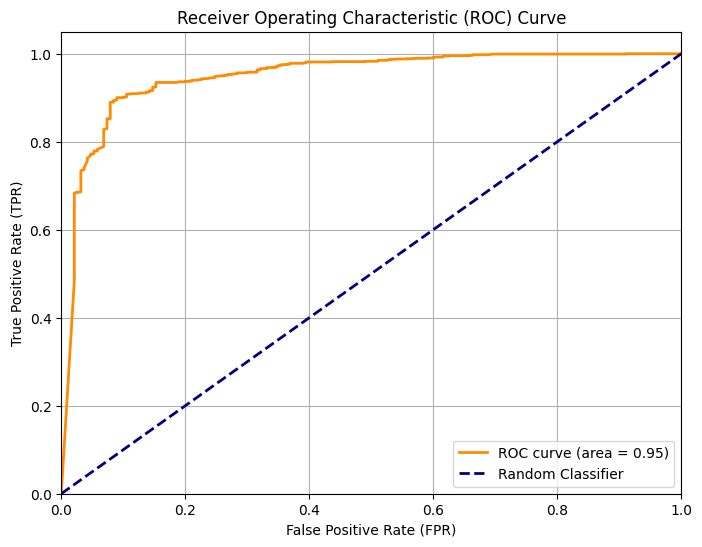

The Area Under the Curve (AUC) is: 0.9487


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import auc

# Extract FPR and TPR values directly from the DataFrame
fpr = df[fpr_column].values
tpr = df[tpr_column].values

# Calculate the Area Under the Curve (AUC)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"The Area Under the Curve (AUC) is: {roc_auc:.4f}")

## Identify True Labels and Prediction Scores

### Subtask:
Guide the user to specify the column names in the DataFrame that correspond to the true labels and the model's prediction scores (probabilities or decision function output) for the ROC curve.


It appears that the uploaded ARFF file, `ROC.arff`, already contains pre-calculated metrics commonly used to plot an ROC curve, specifically `True Positive Rate` (TPR), `False Positive Rate` (FPR), and `Threshold` values. This differs from a dataset with raw true class labels and prediction scores (probabilities/decision function outputs) that would typically be fed into a function like `sklearn.metrics.roc_curve`.

For plotting the ROC curve directly from this DataFrame, we will primarily utilize the `False Positive Rate` and `True Positive Rate` columns. The `Threshold` column can be considered as the `prediction_scores_column` as it represents the decision boundary at which the FPR and TPR values were calculated.

Since a direct `true_labels_column` (e.g., a binary column like 'class') is not present in this pre-computed ROC data, we will acknowledge its absence but proceed with the available FPR and TPR columns for plotting the curve.

**Reasoning**:
Following the explanation of the data structure, I will now provide code to examine the DataFrame and explicitly set the `true_labels_column` and `prediction_scores_column` variables, as per the subtask instructions. This code will also confirm the data types of the relevant columns.



In [ ]:
print("DataFrame head:")
print(df.head())

print("\nDataFrame columns:")
print(df.columns.tolist())

# As explained previously, this ARFF file contains pre-computed ROC points.
# A direct 'true_labels_column' (e.g., actual binary class labels) is not present.
# We will use 'None' to indicate its absence for traditional ROC curve calculation functions.
true_labels_column = None # Placeholder or set to None as direct true labels are not available

# The 'Threshold' column represents the decision boundary scores at which FPR and TPR were calculated.
prediction_scores_column = 'Threshold'

# The columns directly used for plotting the ROC curve are False Positive Rate and True Positive Rate
fpr_column = 'False Positive Rate'
tpr_column = 'True Positive Rate'

print(f"\nAssigned true_labels_column: {true_labels_column}")
print(f"Assigned prediction_scores_column: '{prediction_scores_column}'")
print(f"Assigned FPR column for plotting: '{fpr_column}'")
print(f"Assigned TPR column for plotting: '{tpr_column}'")

# Verify that the identified columns are numerical
# (Only prediction_scores_column, fpr_column, and tpr_column are directly relevant for type checking here)
if prediction_scores_column and prediction_scores_column in df.columns:
    if not pd.api.types.is_numeric_dtype(df[prediction_scores_column]):
        print(f"Warning: '{prediction_scores_column}' is not numeric. Attempting conversion...")
        df[prediction_scores_column] = pd.to_numeric(df[prediction_scores_column], errors='coerce')
    print(f"'{prediction_scores_column}' column type: {df[prediction_scores_column].dtype}")

if fpr_column and fpr_column in df.columns:
    if not pd.api.types.is_numeric_dtype(df[fpr_column]):
        print(f"Warning: '{fpr_column}' is not numeric. Attempting conversion...")
        df[fpr_column] = pd.to_numeric(df[fpr_column], errors='coerce')
    print(f"'{fpr_column}' column type: {df[fpr_column].dtype}")

if tpr_column and tpr_column in df.columns:
    if not pd.api.types.is_numeric_dtype(df[tpr_column]):
        print(f"Warning: '{tpr_column}' is not numeric. Attempting conversion...")
        df[tpr_column] = pd.to_numeric(df[tpr_column], errors='coerce')
    print(f"'{tpr_column}' column type: {df[tpr_column].dtype}")

print("\nColumn identification and type verification complete.")

DataFrame head:
   Instance_number  True Positives  False Negatives  False Positives  \
0              0.0          1333.0              0.0            190.0   
1              1.0          1333.0              0.0            187.0   
2              2.0          1333.0              0.0            183.0   
3              3.0          1333.0              0.0            182.0   
4              4.0          1333.0              0.0            181.0   

   True Negatives  False Positive Rate  True Positive Rate  Precision  Recall  \
0             0.0             1.000000                 1.0   0.875246     1.0   
1             3.0             0.984211                 1.0   0.876974     1.0   
2             7.0             0.963158                 1.0   0.879288     1.0   
3             8.0             0.957895                 1.0   0.879868     1.0   
4             9.0             0.952632                 1.0   0.880449     1.0   

    Fallout  FMeasure  Sample Size      Lift  Threshold  
0  0.1

## Modify Upload ARFF File to Handle Multiple Files

### Subtask:
Adjust the code to allow the upload of multiple ARFF files and store all their filenames for subsequent processing.


**Reasoning**:
The user wants to modify the file upload code to accept multiple ARFF files. I need to update the existing code to iterate through all uploaded files, save each one, and collect all filenames in a list called `arff_filenames`.



In [1]:
from google.colab import files

print("Please upload your ARFF file(s):")
uploaded = files.upload()

arff_filenames = []

# Extract filenames and content
if uploaded:
    for filename, content in uploaded.items():
        print(f"File '{filename}' uploaded successfully.")
        # Save the content to a local file for easier processing
        with open(filename, 'wb') as f:
            f.write(content)
        arff_filenames.append(filename)
    print(f"All uploaded ARFF filenames: {arff_filenames}")
else:
    print("No files were uploaded.")

Please upload your ARFF file(s):


Saving DS_AUC.arff to DS_AUC.arff
Saving J48_AUC.arff to J48_AUC.arff
Saving ONER_AUC.arff to ONER_AUC.arff
Saving REP_AUC.arff to REP_AUC.arff
Saving RF_AUC.arff to RF_AUC.arff
Saving RT_AUC.arff to RT_AUC.arff
File 'DS_AUC.arff' uploaded successfully.
File 'J48_AUC.arff' uploaded successfully.
File 'ONER_AUC.arff' uploaded successfully.
File 'REP_AUC.arff' uploaded successfully.
File 'RF_AUC.arff' uploaded successfully.
File 'RT_AUC.arff' uploaded successfully.
All uploaded ARFF filenames: ['DS_AUC.arff', 'J48_AUC.arff', 'ONER_AUC.arff', 'REP_AUC.arff', 'RF_AUC.arff', 'RT_AUC.arff']


## Iterate and Process Each ARFF File

### Subtask:
Loop through each uploaded ARFF file, load its data, extract 'False Positive Rate', 'True Positive Rate', and 'Threshold' columns, convert them to numeric types, and store the processed data.


**Reasoning**:
I need to iterate through each uploaded ARFF file, load its content, decode byte strings, extract the specified columns, convert them to numeric types, and store the processed data for each file in a list, as per the instructions.



In [2]:
from scipy.io.arff import loadarff
import pandas as pd

processed_roc_data = []

for arff_filename in arff_filenames:
    print(f"\nProcessing file: {arff_filename}")
    try:
        # Load the ARFF file
        data, meta = loadarff(arff_filename)

        # Convert to pandas DataFrame
        df_current = pd.DataFrame(data)

        # Iterate through columns and decode byte strings if necessary
        for col in df_current.columns:
            if df_current[col].dtype == 'object':
                try:
                    df_current[col] = df_current[col].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)
                except AttributeError:
                    # Handle cases where some elements might not be bytes after all
                    pass

        # Identify and convert relevant columns to numeric
        fpr_col_name = 'False Positive Rate'
        tpr_col_name = 'True Positive Rate'
        threshold_col_name = 'Threshold'

        if fpr_col_name in df_current.columns:
            df_current[fpr_col_name] = pd.to_numeric(df_current[fpr_col_name], errors='coerce')
            print(f"Converted '{fpr_col_name}' to numeric (type: {df_current[fpr_col_name].dtype})")
        else:
            print(f"Warning: '{fpr_col_name}' not found in {arff_filename}")
            continue # Skip this file if critical columns are missing

        if tpr_col_name in df_current.columns:
            df_current[tpr_col_name] = pd.to_numeric(df_current[tpr_col_name], errors='coerce')
            print(f"Converted '{tpr_col_name}' to numeric (type: {df_current[tpr_col_name].dtype})")
        else:
            print(f"Warning: '{tpr_col_name}' not found in {arff_filename}")
            continue

        if threshold_col_name in df_current.columns:
            df_current[threshold_col_name] = pd.to_numeric(df_current[threshold_col_name], errors='coerce')
            print(f"Converted '{threshold_col_name}' to numeric (type: {df_current[threshold_col_name].dtype})")
        else:
            print(f"Warning: '{threshold_col_name}' not found in {arff_filename}")
            continue

        # Store the processed data
        processed_roc_data.append({
            'filename': arff_filename,
            'fpr': df_current[fpr_col_name].values,
            'tpr': df_current[tpr_col_name].values,
            'threshold': df_current[threshold_col_name].values
        })
        print(f"Successfully processed {arff_filename}")

    except Exception as e:
        print(f"Error processing {arff_filename}: {e}")

print(f"\nProcessed data for {len(processed_roc_data)} files.")
if processed_roc_data:
    print("First entry in processed_roc_data (sample):")
    print(processed_roc_data[0]['filename'])
    print(f"FPR shape: {processed_roc_data[0]['fpr'].shape}")
    print(f"TPR shape: {processed_roc_data[0]['tpr'].shape}")
    print(f"Threshold shape: {processed_roc_data[0]['threshold'].shape}")


Processing file: DS_AUC.arff
Converted 'False Positive Rate' to numeric (type: float64)
Converted 'True Positive Rate' to numeric (type: float64)
Converted 'Threshold' to numeric (type: float64)
Successfully processed DS_AUC.arff

Processing file: J48_AUC.arff
Converted 'False Positive Rate' to numeric (type: float64)
Converted 'True Positive Rate' to numeric (type: float64)
Converted 'Threshold' to numeric (type: float64)
Successfully processed J48_AUC.arff

Processing file: ONER_AUC.arff
Converted 'False Positive Rate' to numeric (type: float64)
Converted 'True Positive Rate' to numeric (type: float64)
Converted 'Threshold' to numeric (type: float64)
Successfully processed ONER_AUC.arff

Processing file: REP_AUC.arff
Converted 'False Positive Rate' to numeric (type: float64)
Converted 'True Positive Rate' to numeric (type: float64)
Converted 'Threshold' to numeric (type: float64)
Successfully processed REP_AUC.arff

Processing file: RF_AUC.arff
Converted 'False Positive Rate' to num

**Reasoning**:
Now that all ARFF files have been processed and their ROC curve data extracted into `processed_roc_data`, the next step is to plot these ROC curves on a single graph and calculate their respective AUCs, as requested by the main task. I will iterate through `processed_roc_data`, plot each curve using `matplotlib.pyplot`, calculate AUC using `sklearn.metrics.auc`, and then provide a summary.



In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import auc
from IPython.display import Image, display
from google.colab import files # Import files for download functionality

# Re-create the plot as the previous one might have been closed by plt.show()
plt.figure(figsize=(10, 8))

# Plot the baseline random classifier
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')

# Iterate and plot each ROC curve again
for roc_entry in processed_roc_data:
    filename = roc_entry['filename']
    fpr = roc_entry['fpr']
    tpr = roc_entry['tpr']

    # Calculate the Area Under the Curve (AUC)
    roc_auc = auc(fpr, tpr)

    # Plot the ROC curve for the current file
    plt.plot(fpr, tpr, lw=2, label=f'ROC curve for {filename} (area = {roc_auc:.2f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curves for Multiple ARFF Files')
plt.legend(loc='lower right')
plt.grid(True)

# === User input for output type and DPI ===
file_type = input("\nEnter output file type (e.g., png, tif, pdf, jpg): ").strip().lower()
dpi_value_str = input("Enter DPI value (e.g., 300, 600, 900): ").strip()

# Validate file type for saving
valid_save_types = ['png', 'pdf', 'svg', 'jpg', 'jpeg', 'tif']
if file_type not in valid_save_types:
    print(f"Warning: Invalid file type '{file_type}'. Defaulting save to 'png'.")
    file_type = 'png'

# Validate and convert DPI
try:
    dpi_value = int(dpi_value_str)
except ValueError:
    print(f"Warning: Invalid DPI value '{dpi_value_str}'. Defaulting to 300.")
    dpi_value = 300

# === Save and Download ===
output_filename = f"2D-FEL_plot.{file_type}"
plt.savefig(output_filename, dpi=dpi_value, bbox_inches='tight')
print(f"Plot saved as '{output_filename}' with {dpi_value} DPI.")

# === Display the saved image (if embeddable) ===
embeddable_formats = ['png', 'jpg', 'jpeg', 'svg'] # Formats IPython.display.Image can embed
if file_type in embeddable_formats:
    display(Image(filename=output_filename))
else:
    print(f"Note: Image format '{file_type}' cannot be directly displayed in the notebook output, but it has been saved and will be downloaded.")

files.download(output_filename)
plt.close() # Close the plot figure after saving and downloading

plt.show()


Enter output file type (e.g., png, tif, pdf, jpg): tif
Enter DPI value (e.g., 300, 600, 900): 300
Plot saved as '2D-FEL_plot.tif' with 300 DPI.
Note: Image format 'tif' cannot be directly displayed in the notebook output, but it has been saved and will be downloaded.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import auc
from IPython.display import Image, display
from google.colab import files

plt.figure(figsize=(10, 8))

# Baseline random classifier
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')

# Calculate AUC for all curves first to find the max
roc_data_with_auc = []
for roc_entry in processed_roc_data:
    fpr = roc_entry['fpr']
    tpr = roc_entry['tpr']
    roc_auc = auc(fpr, tpr)
    roc_data_with_auc.append({
        'filename': roc_entry['filename'],
        'fpr': fpr,
        'tpr': tpr,
        'auc': roc_auc
    })

# Find the maximum AUC and its corresponding filename
if roc_data_with_auc:
    max_auc_entry = max(roc_data_with_auc, key=lambda x: x['auc'])
    max_auc_filename = max_auc_entry['filename']
else:
    max_auc_filename = None

# Plot ROC curves
for roc_entry in roc_data_with_auc:
    filename = roc_entry['filename']
    fpr = roc_entry['fpr']
    tpr = roc_entry['tpr']
    roc_auc = roc_entry['auc']

    # Ask legend name for each ARFF file
    legend_name = input(f"Enter legend name for file '{filename}': ").strip()

    # If user leaves blank, use filename
    if legend_name == "":
        legend_name = filename

    # Determine plot style based on whether it's the highest AUC
    if filename == max_auc_filename:
        plot_color = 'red'
        line_width = 4
        label_text = f'{legend_name} (AUC = {roc_auc:.3f})'
    else:
        plot_color = None # matplotlib will cycle through default colors
        line_width = 2
        label_text = f'{legend_name} (AUC = {roc_auc:.3f})'

    # Plot ROC
    plt.plot(
        fpr,
        tpr,
        lw=line_width,
        color=plot_color,
        label=label_text
    )

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel('False Positive Rate (FPR)', fontname="DejaVu Serif")
plt.ylabel('True Positive Rate (TPR)', fontname="DejaVu Serif")

plt.title('Receiver Operating Characteristic (ROC) Curves', fontname="DejaVu Serif")

# Correctly applying font to legend using 'prop' argument
plt.legend(loc='lower right', prop={'family': 'DejaVu Serif'})
plt.grid(True)

# Apply DejaVu Serif to x and y axis tick values
ax = plt.gca()
for tick in ax.get_xticklabels():
    tick.set_fontfamily('DejaVu Serif')
for tick in ax.get_yticklabels():
    tick.set_fontfamily('DejaVu Serif')

# === User input for output type and DPI ===
file_type = input("\nEnter output file type (png, tif, pdf, jpg): ").strip().lower()
dpi_value_str = input("Enter DPI value (300, 600, 900): ").strip()

valid_save_types = ['png', 'pdf', 'svg', 'jpg', 'jpeg', 'tif']

if file_type not in valid_save_types:
    print("Invalid type. Defaulting to png.")
    file_type = 'png'

try:
    dpi_value = int(dpi_value_str)
except ValueError:
    print("Invalid DPI value. Defaulting to 300.")
    dpi_value = 300

# Save
output_filename = f"ROC_plot.{file_type}"
plt.savefig(output_filename, dpi=dpi_value, bbox_inches='tight')
print(f"Plot saved as '{output_filename}' with {dpi_value} DPI.")

# === Display the saved image (if embeddable) ===
embeddable_formats = ['png', 'jpg', 'jpeg', 'svg'] # Formats IPython.display.Image can embed
if file_type in embeddable_formats:
    display(Image(filename=output_filename))
else:
    print(f"Note: Image format '{file_type}' cannot be directly displayed in the notebook output, but it has been saved and will be downloaded.")

files.download(output_filename)

plt.close() # Close the plot figure after saving and downloading

Enter legend name for file 'DS_AUC.arff': Decision Stump
Enter legend name for file 'J48_AUC.arff': J48
Enter legend name for file 'ONER_AUC.arff': OneR
Enter legend name for file 'REP_AUC.arff': REP Tree
Enter legend name for file 'RF_AUC.arff': Random Forest
Enter legend name for file 'RT_AUC.arff': Random Tree

Enter output file type (png, tif, pdf, jpg): tif
Enter DPI value (300, 600, 900): 300
Plot saved as 'ROC_plot.tif' with 300 DPI.
Note: Image format 'tif' cannot be directly displayed in the notebook output, but it has been saved and will be downloaded.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>